# Descriptive Analysis: Par3

**Dataset:** Karpinska, Thai, Krishna, Wieting, Inghilleri & Iyyer (2022). *Par3: A Parallel Corpus of Paragraph-Aligned Translations from World Literature.*
https://github.com/katherinethai/par3

**Task:**
- Literary translation diversity
- 113 public-domain novels across 16 source languages
- Each with paragraph-aligned Google Translate output
- Each with 2-5 independent human-translator English translations of the same source paragraphs

In [24]:
# Load libraries
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import warnings
warnings.filterwarnings('ignore')

In [26]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_PATH = '../data/par3/par3.pkl'

# Load the pooled Par3 dataset
with open(DATA_PATH, 'rb') as f:
    par3 = pickle.load(f)

print(f'Loaded {len(par3)} books')

# Shared setup for the combined, cross-language analysis below: 
# define the candidate languages, their display names/colors, and the
# per-language book subsets

CANDIDATE_LANGS = ['de', 'fr', 'ru', 'zh']
LANG_NAMES = {'de': 'German', 'fr': 'French', 'ru': 'Russian', 'zh': 'Chinese'}
LANG_COLORS = {'de': '#4C72B0', 'fr': '#DD8452', 'ru': '#55A868', 'zh': '#C44E52'}
lang_books = {lang: {k: v for k, v in par3.items() if k.endswith(f'_{lang}')} for lang in CANDIDATE_LANGS}
LANGUAGES = [(LANG_NAMES[lang], lang_books[lang]) for lang in CANDIDATE_LANGS]

Loaded 113 books


## Corpus overview

Each book is `{source_paras, gt_paras, translator_data}`, where:
- `translator_data` maps `translator_k -> {translator_paras, sent_alignments}`
- `source_paras`, `gt_paras` and every translator's `translator_paras` share the same index space within a book    
-> index `i` always refers to the same underlying source passage across source/GT/all translators.

In [27]:
# Book-level summary table
records = []
for book_id, book in par3.items():
    lang = book_id.rsplit('_', 1)[-1]
    records.append({
        'book_id': book_id,
        'source_lang': lang,
        'n_translators': len(book['translator_data']),
        'n_paragraphs': len(book['source_paras']),
    })
books_df = pd.DataFrame(records)

print('Source languages:')
print(books_df['source_lang'].value_counts())
print()
print('N translators per book:')
print(books_df['n_translators'].value_counts().sort_index())
print()
print('Candidate languages for the combined analysis below:')
for lang in CANDIDATE_LANGS:
    print(f'  {LANG_NAMES[lang]}: {len(lang_books[lang])} books')

Source languages:
source_lang
fr    32
ru    26
de    15
ja     9
zh     7
no     5
cs     4
pt     4
sv     3
it     2
es     1
hu     1
pl     1
nl     1
ta     1
fa     1
Name: count, dtype: int64

N translators per book:
n_translators
2    86
3    22
4     4
5     1
Name: count, dtype: int64

Candidate languages for the combined analysis below:
  German: 15 books
  French: 32 books
  Russian: 26 books
  Chinese: 7 books


In [40]:
# Overview table: all 16 source languages in the raw Par3 corpus (not just the 4 candidate
# languages used in the combined analysis below). For each language: total books/paragraphs,
# plus how many paragraphs (and books contributing at least one) have a non-empty translation
# from >= 2/3/4 translators at that paragraph index -- translator_k coverage varies by index,
# e.g. German translator_3/4 only cover a subset of paragraphs (see word-count table below).
# Unlike the "Summary table" section further down, this has no MIN_SENTENCES filter -- it's
# purely translator presence, since that section's threshold is metrics_lib-specific.
LANG_NAMES_ALL = {
    'fr': 'French', 'ru': 'Russian', 'de': 'German', 'ja': 'Japanese', 'zh': 'Chinese',
    'no': 'Norwegian', 'cs': 'Czech', 'pt': 'Portuguese', 'sv': 'Swedish', 'it': 'Italian',
    'es': 'Spanish', 'hu': 'Hungarian', 'pl': 'Polish', 'nl': 'Dutch', 'ta': 'Tamil', 'fa': 'Persian',
}
COVERAGE_THRESHOLDS = (2, 3, 4)

coverage_rows = []
for book_id, book in par3.items():
    lang = book_id.rsplit('_', 1)[-1]
    translators = list(book['translator_data'].values())
    n_paras = len(book['source_paras'])
    counts = {t: 0 for t in COVERAGE_THRESHOLDS}

    # For each paragraph index, count how many translators have a non-empty translation there
    for i in range(n_paras):
        n_present = sum(
            1 for tr in translators
            if i < len(tr['translator_paras']) and tr['translator_paras'][i] and tr['translator_paras'][i].strip()
        )
        for t in COVERAGE_THRESHOLDS:
            if n_present >= t:
                counts[t] += 1

    row = {'book_id': book_id, 'source_lang': lang}
    row.update({f'paragraphs_ge{t}t': counts[t] for t in COVERAGE_THRESHOLDS})
    coverage_rows.append(row)
coverage_books_df = pd.DataFrame(coverage_rows)

lang_overview_all = books_df.groupby('source_lang').agg(
    n_books=('book_id', 'nunique'), n_paragraphs=('n_paragraphs', 'sum')
)
for t in COVERAGE_THRESHOLDS:
    lang_overview_all[f'paragraphs_>={t}_translators'] = (
        coverage_books_df.groupby('source_lang')[f'paragraphs_ge{t}t'].sum())
    lang_overview_all[f'books_>={t}_translators'] = (
        coverage_books_df[coverage_books_df[f'paragraphs_ge{t}t'] > 0]
        .groupby('source_lang')['book_id'].nunique()
        .reindex(lang_overview_all.index).fillna(0).astype(int))

lang_overview_all = lang_overview_all.rename(index=LANG_NAMES_ALL).sort_values('n_books', ascending=False)
lang_overview_all.index.name = 'language'
lang_overview_all.loc['Total'] = lang_overview_all.sum()

display(lang_overview_all)

,n_books,n_paragraphs,paragraphs_>=2_translators,books_>=2_translators,paragraphs_>=3_translators,books_>=3_translators,paragraphs_>=4_translators,books_>=4_translators
language,,,,,,,,
French,32,51052,51039,32,12087,6,0,0
Russian,26,34030,34025,26,14621,12,3707,3
German,15,8905,8903,15,1026,5,82,1
Japanese,9,2483,2482,9,19,1,0,0
Chinese,7,3671,3660,7,441,1,280,1
Norwegian,5,4756,4756,5,651,1,0,0
Czech,4,2886,2856,4,0,0,0,0
Portuguese,4,3261,3011,4,0,0,0,0
Swedish,3,2591,2591,3,0,0,0,0


## Paragraph length distribution

`metrics_lib`'s D_narr needs >= 10 sentences per text (`MIN_SENTENCES` in `narrative.py`, tied to `ARC_LENGTH=10`)

German: n=8905, mean=3.73, median=2.0, % >= 10 sentences=7.3%
French: n=51052, mean=2.55, median=1.0, % >= 10 sentences=3.0%
Russian: n=34030, mean=3.28, median=2.0, % >= 10 sentences=5.8%
Chinese: n=3671, mean=4.70, median=2.0, % >= 10 sentences=14.3%


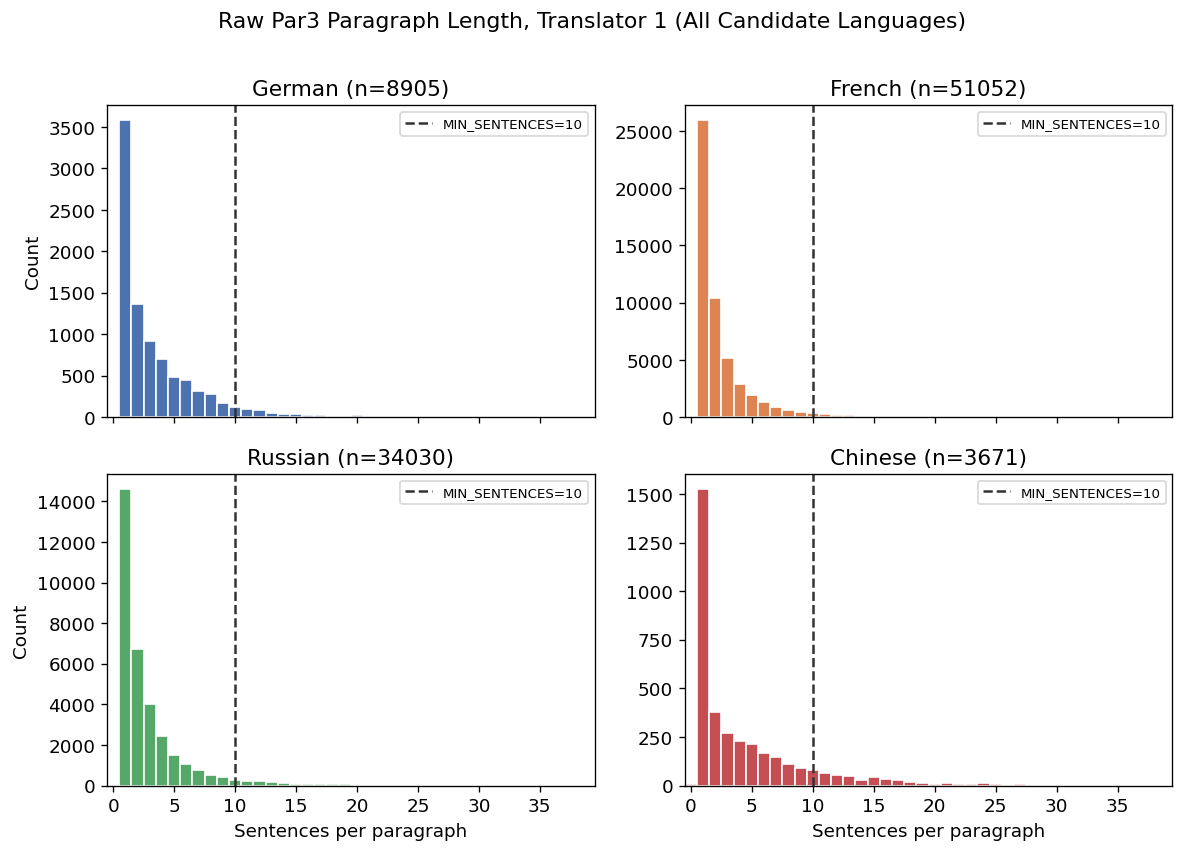

In [28]:
# Helper function to count sentences in a paragraph
def n_sentences(text):
    if not text or not text.strip():
        return 0
    return len(sent_tokenize(text))

# Sentence counts per paragraph, first translator of every book, per candidate language
para_sent_counts_by_lang = {}
for lang in CANDIDATE_LANGS:
    counts = []

    # For each book in the language, get the first translator's paragraphs and count sentences
    for book in lang_books[lang].values():
        first_translator = next(iter(book['translator_data'].values()))
        counts.extend(n_sentences(p) for p in first_translator['translator_paras'])

    # Store the counts as a NumPy array
    para_sent_counts_by_lang[lang] = np.array(counts)

# Print summary statistics for each candidate language
for lang in CANDIDATE_LANGS:
    counts = para_sent_counts_by_lang[lang]
    print(f'{LANG_NAMES[lang]}: n={len(counts)}, mean={counts.mean():.2f}, '
          f'median={np.median(counts):.1f}, % >= 10 sentences={100*np.mean(counts >= 10):.1f}%')

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for ax, lang in zip(axes.flat, CANDIDATE_LANGS):
    counts = para_sent_counts_by_lang[lang]
    ax.hist(counts, bins=np.arange(0, 40) - 0.5, color=LANG_COLORS[lang], edgecolor='white')
    ax.axvline(10, color='#333333', linestyle='--', linewidth=1.5, label='MIN_SENTENCES=10')
    ax.set_title(f'{LANG_NAMES[lang]} (n={len(counts)})')
    ax.set_xlim(-0.5, 39.5)
    ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Sentences per paragraph')
for ax in axes[:, 0]:
    ax.set_ylabel('Count')
fig.suptitle('Raw Par3 Paragraph Length, Translator 1 (All Candidate Languages)', y=1.01)
plt.tight_layout()
plt.savefig('../figures/data_description/par3_paragraph_sentence_counts.png', dpi=300, bbox_inches='tight')
plt.show()

## Paragraph length in words and sentences

- `translator_1`/`translator_2` are present in every book across all four languages
- `translator_3`+ only exist for the subset of books with that many translators

In [31]:
from nltk.tokenize import word_tokenize

# Helper function to count words in a list of paragraphs
def word_counts(paras):
    return np.array([len(word_tokenize(p)) for p in paras if p and p.strip()])

length_rows = []
for lang in CANDIDATE_LANGS:
    src_words, gt_words = [], []
    translator_words = {}

    # For each book in the language, get the source, GT and translator paragraphs and count words
    for book in lang_books[lang].values():
        src_words.extend(word_counts(book['source_paras']))
        gt_words.extend(word_counts(book['gt_paras']))
        for tname, tdata in book['translator_data'].items():
            translator_words.setdefault(tname, []).extend(word_counts(tdata['translator_paras']))

    # Store the word counts for each group (source, GT, translators) in the length_rows list
    groups = [('SOURCE', np.array(src_words)), ('GOOGLE TRANSLATE', np.array(gt_words))]
    groups += [(tname, np.array(w)) for tname, w in sorted(translator_words.items())]

    # Compute summary statistics for each group and append to length_rows
    for name, w in groups:
        length_rows.append({
            'language': LANG_NAMES[lang], 'group': name, 'n_paragraphs': len(w),
            'mean_words': w.mean(), 'median_words': np.median(w), 'std_words': w.std(),
        })

length_df = pd.DataFrame(length_rows)
length_df.to_csv('../data_description/par3_paragraph_word_counts.csv', index=False)
length_df

,language,group,n_paragraphs,mean_words,median_words,std_words
0,German,SOURCE,8905,84.48,41.00,143.79
1,German,GOOGLE TRANSLATE,8905,86.24,41.00,147.26
2,German,translator_1,8903,90.93,45.00,154.08
3,German,translator_2,8903,91.93,45.00,157.73
4,German,translator_3,1026,140.82,61.50,350.37
5,German,translator_4,83,592.24,198.00,983.32
6,French,SOURCE,51052,51.26,25.00,84.77
7,French,GOOGLE TRANSLATE,51052,49.01,24.00,78.78
8,French,translator_1,51040,52.83,28.00,92.41
9,French,translator_2,51039,53.37,27.00,99.59


In [32]:
# Sentence counts per paragraph, all translators of every book, per candidate language
translator_sents_by_lang = {}
sent_rows = []
for lang in CANDIDATE_LANGS:
    src_sents, gt_sents = [], []
    translator_sents = {}
    for book in lang_books[lang].values():
        src_sents.extend(n_sentences(p) for p in book['source_paras'] if p and p.strip())
        gt_sents.extend(n_sentences(p) for p in book['gt_paras'] if p and p.strip())
        for tname, tdata in book['translator_data'].items():
            translator_sents.setdefault(tname, []).extend(
                n_sentences(p) for p in tdata['translator_paras'] if p and p.strip()
            )
    translator_sents_by_lang[lang] = translator_sents

    groups = [('SOURCE', np.array(src_sents)), ('GOOGLE TRANSLATE', np.array(gt_sents))]
    groups += [(tname, np.array(s)) for tname, s in sorted(translator_sents.items())]
    for name, s in groups:
        sent_rows.append({
            'language': LANG_NAMES[lang], 'group': name, 'n_paragraphs': len(s),
            'mean_sentences': s.mean(), 'median_sentences': np.median(s), 'std_sentences': s.std(),
        })

sent_len_df = pd.DataFrame(sent_rows)
sent_len_df

,language,group,n_paragraphs,mean_sentences,median_sentences,std_sentences
0,German,SOURCE,8905,3.37,2.00,5.04
1,German,GOOGLE TRANSLATE,8905,3.62,2.00,5.79
2,German,translator_1,8903,3.73,2.00,5.16
3,German,translator_2,8903,3.87,2.00,5.97
4,German,translator_3,1026,5.05,3.00,11.00
5,German,translator_4,83,22.45,7.00,38.52
6,French,SOURCE,51052,2.50,2.00,3.05
7,French,GOOGLE TRANSLATE,51052,2.56,2.00,3.11
8,French,translator_1,51040,2.55,1.00,3.41
9,French,translator_2,51039,2.43,1.00,3.83


## Filtering translation paragraphs by minimum sentence count

ALL TRANSLATORS pool size, per language: {'German': 18915, 'French': 114166, 'Russian': 87196, 'Chinese': 8045}
% of translator paragraphs retained (ALL TRANSLATORS pool), by language and threshold:


language,German,French,Russian,Chinese
min_sentences,,,,
4,35.00,18.10,23.30,46.90
5,27.00,12.40,16.50,41.10
6,21.30,8.90,12.30,35.70
7,16.50,6.50,9.50,31.40
8,13.00,4.90,7.40,27.70
9,9.90,3.70,6.10,24.50
10,7.90,2.90,5.00,21.80


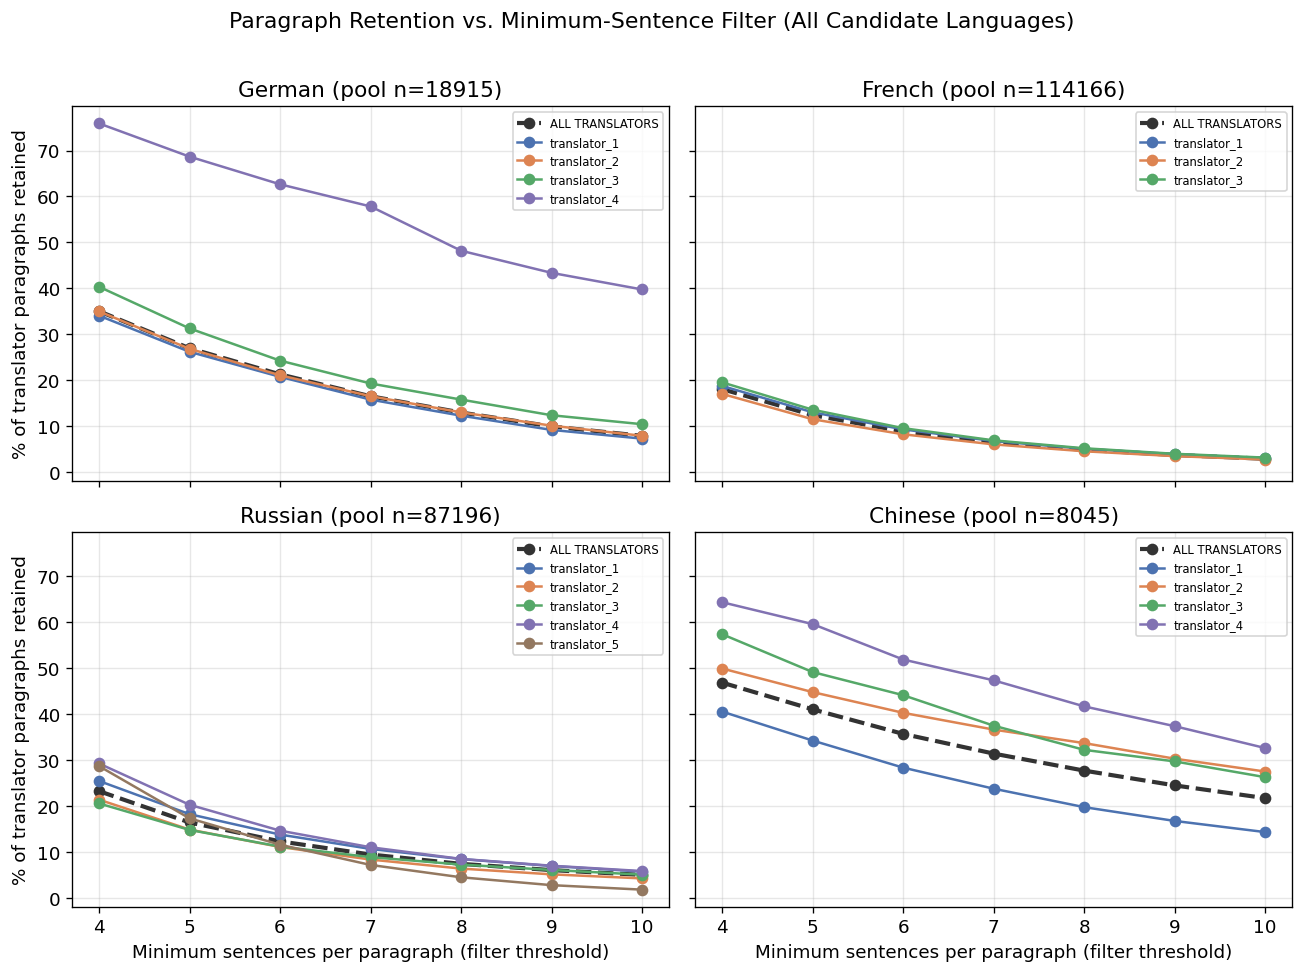

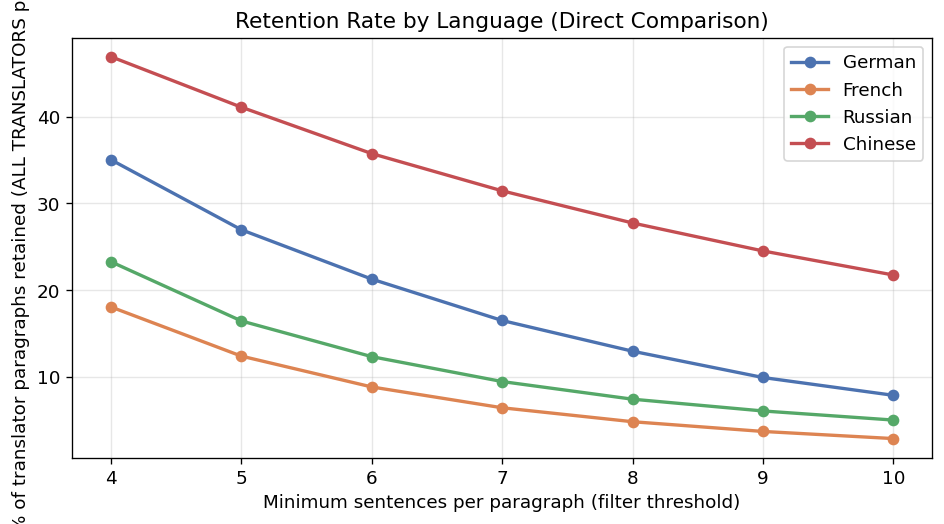

In [33]:
thresholds = list(range(4, 11))
translator_color_map = {'translator_1': '#4C72B0', 'translator_2': '#DD8452', 'translator_3': '#55A868',
                         'translator_4': '#8172B2', 'translator_5': '#937860', 'ALL TRANSLATORS': '#333333'}

all_filter_df = []
pool_n = {}

# Compute the number of paragraphs retained at each threshold for each translator and for the combined "ALL TRANSLATORS" pool
for lang in CANDIDATE_LANGS:
    translator_sents = translator_sents_by_lang[lang]
    rows = []

    # For each translator, compute the number of paragraphs retained at each threshold
    for tname, counts in sorted(translator_sents.items()):
        counts = np.array(counts)
        for t in thresholds:
            n_pass = int(np.sum(counts >= t))
            rows.append({'language': lang, 'group': tname, 'min_sentences': t,
                         'n_paragraphs': n_pass, 'pct_retained': 100 * n_pass / len(counts)})

    # For the combined "ALL TRANSLATORS" pool, compute the number of paragraphs retained at each threshold
    all_counts = np.concatenate([np.array(s) for s in translator_sents.values()])
    pool_n[lang] = len(all_counts)
    for t in thresholds:
        n_pass = int(np.sum(all_counts >= t))
        rows.append({'language': lang, 'group': 'ALL TRANSLATORS', 'min_sentences': t,
                     'n_paragraphs': n_pass, 'pct_retained': 100 * n_pass / len(all_counts)})
    all_filter_df.append(pd.DataFrame(rows))


all_filter_df = pd.concat(all_filter_df, ignore_index=True)

print('ALL TRANSLATORS pool size, per language:', {LANG_NAMES[l]: pool_n[l] for l in CANDIDATE_LANGS})

summary_pivot = all_filter_df[all_filter_df['group'] == 'ALL TRANSLATORS'].pivot(
    index='min_sentences', columns='language', values='pct_retained'
).rename(columns=LANG_NAMES).round(1)
print('% of translator paragraphs retained (ALL TRANSLATORS pool), by language and threshold:')
display(summary_pivot)

# Figure: small multiples, one subplot per language, all translator slots + ALL TRANSLATORS
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, lang in zip(axes.flat, CANDIDATE_LANGS):
    sub_lang = all_filter_df[all_filter_df['language'] == lang]
    for group, sub in sub_lang.groupby('group'):
        sub = sub.sort_values('min_sentences')
        lw, ls = (2.5, '--') if group == 'ALL TRANSLATORS' else (1.5, '-')
        ax.plot(sub['min_sentences'], sub['pct_retained'], marker='o', label=group,
                color=translator_color_map.get(group), linewidth=lw, linestyle=ls)
    ax.set_title(f'{LANG_NAMES[lang]} (pool n={pool_n[lang]})')
    ax.set_xticks(thresholds)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel('Minimum sentences per paragraph (filter threshold)')
for ax in axes[:, 0]:
    ax.set_ylabel('% of translator paragraphs retained')
fig.suptitle('Paragraph Retention vs. Minimum-Sentence Filter (All Candidate Languages)', y=1.01)
plt.tight_layout()
plt.savefig('../figures/data_description/par3_min_sentence_filter.png', dpi=300, bbox_inches='tight')
plt.show()

# Direct cross-language comparison: ALL TRANSLATORS retention curve only
fig, ax = plt.subplots(figsize=(8, 4.5))
for lang in CANDIDATE_LANGS:
    sub = all_filter_df[(all_filter_df['language'] == lang) & (all_filter_df['group'] == 'ALL TRANSLATORS')].sort_values('min_sentences')
    ax.plot(sub['min_sentences'], sub['pct_retained'], marker='o', label=LANG_NAMES[lang],
            color=LANG_COLORS[lang], linewidth=2)
ax.set_xlabel('Minimum sentences per paragraph (filter threshold)')
ax.set_ylabel('% of translator paragraphs retained (ALL TRANSLATORS pool)')
ax.set_title('Retention Rate by Language (Direct Comparison)')
ax.set_xticks(thresholds)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/data_description/par3_min_sentence_filter_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

## Translator coverage: how many translators survive the filter per paragraph

In [35]:
# Compute the number of usable paragraph indices at each threshold, for each language, 
# for different minimum numbers of simultaneous translators
def translator_coverage(books, thresholds=thresholds, min_translators=2):
    rows = []

    # For each threshold, count the total paragraph indices and the usable ones based on the minimum number of translators
    for t in thresholds:
        total_indices, usable_indices = 0, 0
        n_translators_usable = []

        # For each book, count the number of translators that have at least t sentences in each paragraph
        for book_id, book in books.items():
            translators = list(book['translator_data'].values())
            n_paras = len(book['source_paras'])

            # For each paragraph index, count how many translators meet the minimum sentence threshold
            for i in range(n_paras):
                n_pass = sum(
                    1 for tr in translators
                    if i < len(tr['translator_paras']) and n_sentences(tr['translator_paras'][i]) >= t
                )
                total_indices += 1

                # If the number of translators meeting the threshold is greater than or equal to the minimum required, count it as usable
                if n_pass >= min_translators:
                    usable_indices += 1
                    n_translators_usable.append(n_pass)


        rows.append({
            'min_sentences': t,
            'total_indices': total_indices,
            'usable_indices': usable_indices,
            'pct_usable': 100 * usable_indices / total_indices,
            'avg_translators_per_usable_index': np.mean(n_translators_usable) if n_translators_usable else 0.0,
        })
    return pd.DataFrame(rows)

min_translator_levels = (2, 3, 4)

# Compute the coverage for each language and each minimum translator level
coverage_parts = []
for lang_name, books in LANGUAGES:
    for min_t in min_translator_levels:
        part = translator_coverage(books, min_translators=min_t)
        part.insert(0, 'min_translators', min_t)
        part.insert(0, 'language', lang_name)
        coverage_parts.append(part)

coverage_df = pd.concat(coverage_parts, ignore_index=True)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(coverage_df)

print('Usable paragraphs at MIN_SENTENCES=10, by minimum simultaneous translators:')
summary_10 = coverage_df[coverage_df['min_sentences'] == 10].pivot(
    index='language', columns='min_translators', values='usable_indices'
)
summary_10.columns = [f'>= {c} translators' for c in summary_10.columns]
display(summary_10)

,language,min_translators,min_sentences,total_indices,usable_indices,pct_usable,avg_translators_per_usable_index
0,German,2,4,8905,2819,31.66,2.15
1,German,2,5,8905,2138,24.01,2.16
2,German,2,6,8905,1656,18.60,2.16
3,German,2,7,8905,1261,14.16,2.17
4,German,2,8,8905,986,11.07,2.17
...,...,...,...,...,...,...,...
79,Chinese,4,6,3671,85,2.32,4.00
80,Chinese,4,7,3671,67,1.83,4.00
81,Chinese,4,8,3671,51,1.39,4.00
82,Chinese,4,9,3671,44,1.20,4.00


Usable paragraphs at MIN_SENTENCES=10, by minimum simultaneous translators:


,>= 2 translators,>= 3 translators,>= 4 translators
language,,,
Chinese,481,111,33
French,1141,318,0
German,565,85,27
Russian,1512,581,151


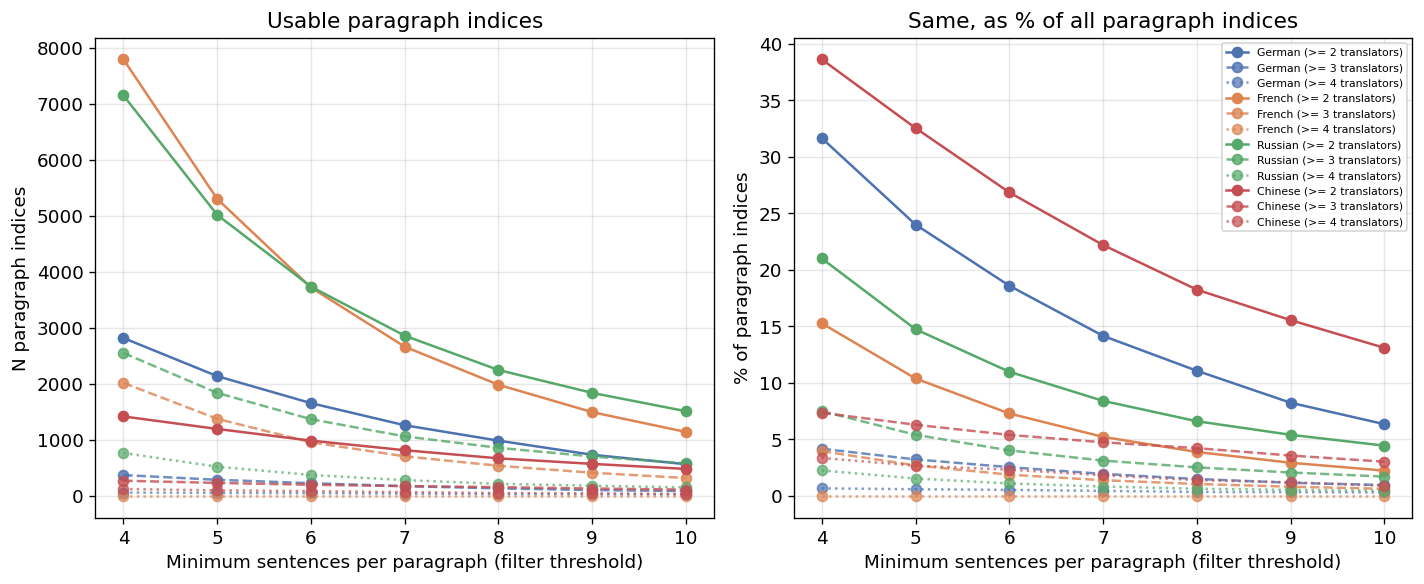

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {LANG_NAMES[l]: LANG_COLORS[l] for l in CANDIDATE_LANGS}
linestyles = {2: ('-', 1.0), 3: ('--', 0.8), 4: (':', 0.7)}
for lang_name, _ in LANGUAGES:
    for min_t in min_translator_levels:
        ls, alpha = linestyles[min_t]
        sub = coverage_df[(coverage_df['language'] == lang_name) & (coverage_df['min_translators'] == min_t)].sort_values('min_sentences')
        label = f'{lang_name} (>= {min_t} translators)'
        axes[0].plot(sub['min_sentences'], sub['usable_indices'], marker='o', label=label,
                     color=colors[lang_name], linestyle=ls, alpha=alpha)
        axes[1].plot(sub['min_sentences'], sub['pct_usable'], marker='o', label=label,
                     color=colors[lang_name], linestyle=ls, alpha=alpha)

axes[0].set_title('Usable paragraph indices')
axes[0].set_ylabel('N paragraph indices')
axes[1].set_title('Same, as % of all paragraph indices')
axes[1].set_ylabel('% of paragraph indices')
for ax in axes:
    ax.set_xlabel('Minimum sentences per paragraph (filter threshold)')
    ax.set_xticks(thresholds)
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=6.5, ncol=1, loc='upper right')
plt.tight_layout()
plt.savefig('../figures/data_description/par3_translator_coverage_de_fr_ru_zh.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary table

In [39]:
summary_rows = []
for lang_name, books in LANGUAGES:
    n_books = len(books)
    total_paragraphs = sum(len(b['source_paras']) for b in books.values())
    max_translators = max(len(b['translator_data']) for b in books.values())
    row = {
        'Language': lang_name,
        'Books': n_books,
        'Total paragraphs': total_paragraphs,
        'Max translators/book': max_translators,
    }
    for min_t in (2, 3, 4):
        sub = coverage_df[(coverage_df['language'] == lang_name) & (coverage_df['min_translators'] == min_t)
                           & (coverage_df['min_sentences'] == 10)]
        n = int(sub['usable_indices'].iloc[0])
        pct = sub['pct_usable'].iloc[0]
        row[f'>= {min_t} translators'] = f'{n} ({pct:.1f}%)'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Language')
display(summary_df)

,Books,Total paragraphs,Max translators/book,>= 2 translators,>= 3 translators,>= 4 translators
Language,,,,,,
German,15,8905,4,565 (6.3%),85 (1.0%),27 (0.3%)
French,32,51052,3,1141 (2.2%),318 (0.6%),0 (0.0%)
Russian,26,34030,5,1512 (4.4%),581 (1.7%),151 (0.4%)
Chinese,7,3671,4,481 (13.1%),111 (3.0%),33 (0.9%)
